In [ ]:
# --- Inputs: set once per recording/sorting run ---
raw_data_folder = r"C:\SGL_DATA\20260625_exp1_g0\20260625_exp1_g0_imec0"
sorter_output_path = r"C:\Sorted_spikes\kilosort4_imec_ap_20260625_exp1_job46233787\sorter_output"
nidq_file_path = r"C:\\SGL_DATA\\20260625_exp1_g0"  # folder containing the .nidq.bin/.meta (BNC channels)

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import spikeinterface.extractors as se
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt


In [ ]:
# Load the raw SpikeGLX recording (extracts metadata automatically)
recording = se.read_spikeglx(folder_path=raw_data_folder, stream_id="imec0.ap")

# Load the Kilosort sorting output directly
sorting = se.read_kilosort(folder_path=sorter_output_path)

# Register the recording with the sorting to enable time-based operations.
# Note: SortingExtractor has no `set_recording` method - the correct API is `register_recording`.
sorting.register_recording(recording)

# Get the exact sampling frequency directly from the .meta file
sampling_frequency = recording.get_sampling_frequency()
print(f"Successfully linked! Sampling frequency from .meta: {sampling_frequency} Hz")

# SpikeGLX times spikes from acquisition start, not from when recording/gate was
# enabled. The gap between the two is `firstSample` (samples) in the .meta file,
# which spikeinterface already folds into recording.get_start_time(). Subtract it
# so spike times are zeroed to when recording was actually enabled.
recording_start_offset_s = recording.get_start_time()
print(f"Recording start offset (acquisition start -> recording enabled): {recording_start_offset_s:.6f} s")

# Outputs go one directory up from the Kilosort sorter output folder
export_dir = os.path.dirname(sorter_output_path)

# --- Quality labels: curated cluster_group.tsv if it exists, else Kilosort's own cluster_KSLabel.tsv ---
labels_path = os.path.join(sorter_output_path, "cluster_group.tsv")
if not os.path.exists(labels_path):
    labels_path = os.path.join(sorter_output_path, "cluster_KSLabel.tsv")
labels_df = pd.read_csv(labels_path, sep="\t")
label_col = "group" if "group" in labels_df.columns else "KSLabel"
unit_quality = dict(zip(labels_df["cluster_id"], labels_df[label_col]))

# --- Peak channel per unit, from the Kilosort templates ---
templates = np.load(os.path.join(sorter_output_path, "templates.npy"))
peak_channel = {
    unit_id: int(np.argmax(np.max(np.abs(templates[unit_id]), axis=0)))
    for unit_id in sorting.get_unit_ids()
}

unit_ids = sorting.get_unit_ids()

# --- Spike times per unit, organized by unit, zeroed to recording-enabled time ---
spike_trains = {
    unit_id: np.sort(sorting.get_unit_spike_train(unit_id, return_times=True)) - recording_start_offset_s
    for unit_id in unit_ids
}
print(f"Total spikes: {sum(t.size for t in spike_trains.values())}, units: {sorting.get_num_units()}")

# --- Per-unit record: actual spike timestamps (not binned) plus qc label and channel. ---
# Units have different spike counts, so this is a dict/list rather than a rectangular
# numpy array - each unit's "row" is its own variable-length array of spike times (s).
unit_data = {
    unit_id: {
        "spike_times_s": spike_trains[unit_id],
        "quality_label": unit_quality.get(unit_id, "unknown"),
        "channel": peak_channel.get(unit_id, -1),
    }
    for unit_id in unit_ids
}

unit_data_path = os.path.join(export_dir, "unit_spike_data.pkl")
with open(unit_data_path, "wb") as f:
    pickle.dump(unit_data, f)
print(f"Saved per-unit spike data to: {unit_data_path}")

`unit_spike_data.pkl` schema

Loading: `unit_data = pickle.load(open("unit_spike_data.pkl", "rb"))`

`unit_data` is a `dict` keyed by `unit_id` (int). Each value is itself a `dict` with:

| Key | Type | Meaning |
| --- | --- | --- |
| `spike_times_s` | `np.ndarray[float]`, variable length per unit | Sorted spike timestamps in seconds, relative to recording start |
| `quality_label` | `str` | Kilosort/curated QC label (e.g. `"good"`, `"mua"`, `"noise"`, `"unknown"`) |
| `channel` | `int` | Peak (max-amplitude) channel index for that unit |

Example: `unit_data[123]["spike_times_s"]` -> spike times for unit 123; `unit_data[123]["channel"]` -> its peak channel.


In [ ]:
# select all the LGN units (label "good") for downstream analysis
unit_data = pickle.load(open("kilosort4_imec_ap_20260625_exp1_job46233787\\unit_spike_data.pkl", "rb"))
lgn_channel_range = range(10, 51)  # inclusive LGN channel range
lgn_units = [
    unit_id
    for unit_id, record in unit_data.items()
    if record["quality_label"] == "good" and record["channel"] in lgn_channel_range
]
# unwanted_units = [22, 48]
# lgn_units = [unit_id for unit_id in lgn_units if unit_id not in unwanted_units]
# lgn_units = [27, 30, 31, 32, 33]
lgn_units = [unit_id for unit_id in lgn_units if unit_data[unit_id]["spike_times_s"].size < 100000]  # filter out units with too many spikes

spike_counts = [unit_data[unit_id]["spike_times_s"].size for unit_id in lgn_units]
plt.figure(figsize=(8, 4))
plt.hist(spike_counts, bins=20)
plt.xlabel("Spike count")
plt.ylabel("Number of units")
plt.title(f"Spike count distribution across {len(lgn_units)} LGN units")
plt.tight_layout()
plt.show()


In [ ]:
# raster plotting function for LGN units, optionally aligned to chirp onset detected in BNC channel
lgn_spike_times = {
    unit_id: unit_data[unit_id]["spike_times_s"]
    for unit_id in lgn_units
}
print(f"Selected {len(lgn_units)} good LGN units for downstream analysis")

def _load_bnc_window(nidq_recording, nidq_fs, bnc_channel_id, t0, t1):
    start_frame = max(0, int(t0 * nidq_fs))
    end_frame = min(nidq_recording.get_num_samples(), int(t1 * nidq_fs))
    trace = nidq_recording.get_traces(
        channel_ids=[bnc_channel_id], start_frame=start_frame, end_frame=end_frame
    ).flatten()
    time = np.arange(start_frame, end_frame) / nidq_fs
    return time, trace

def _detect_chirp_onsets(time, trace, threshold, min_isi_s):
    thr = threshold if threshold is not None else (trace.max().astype(float) + trace.min()) / 2
    above = trace > thr
    rising_edges = np.flatnonzero(~above[:-1] & above[1:]) + 1
    onsets = time[rising_edges]
    if onsets.size:
        keep = np.diff(onsets, prepend=-np.inf) > min_isi_s
        onsets = onsets[keep]
    return onsets

def plot_raster(start_time_s, lapse_s, spike_times=None, bnc_channel=0, chirp_threshold=None,
                 min_isi_s=30.0, align_to_chirp=True, align_offset_s=0.5):
    if spike_times is None:
        spike_times = lgn_spike_times

    show_bnc = bool(nidq_file_path)
    nidq_recording = nidq_fs = bnc_channel_id = None
    if show_bnc:
        nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
        nidq_fs = nidq_recording.get_sampling_frequency()
        bnc_channel_id = nidq_recording.channel_ids[bnc_channel]

        if align_to_chirp:
            # nidq is zeroed to its own recording-enabled offset the same way imec is
            # (see recording_start_offset_s above), so start_time_s/end_time_s already
            # line up with the spike raster without any extra shift.
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, start_time_s, start_time_s + lapse_s
            )
            onset_candidates = _detect_chirp_onsets(search_time, search_trace, chirp_threshold, min_isi_s)
            if onset_candidates.size:
                start_time_s = onset_candidates[0] - align_offset_s
                print(f"Detected chirp onset at {onset_candidates[0]:.4f}s -> "
                      f"re-centered window to start at {start_time_s:.4f}s")

    end_time_s = start_time_s + lapse_s

    if show_bnc:
        fig, (bnc_ax, raster_ax) = plt.subplots(
            2, 1, sharex=True, figsize=(12, 0.3 * len(spike_times) + 3),
            gridspec_kw={"height_ratios": [1, 4]},
        )
    else:
        fig, raster_ax = plt.subplots(figsize=(12, 0.3 * len(spike_times) + 1))

    for row, (unit_id, times) in enumerate(spike_times.items()):
        window = times[(times >= start_time_s) & (times < end_time_s)]
        raster_ax.vlines(window, row, row + 0.8)
    raster_ax.set_yticks(np.arange(len(spike_times)) + 0.4)
    raster_ax.set_yticklabels([
        f"{unit_id} (ch{unit_data[unit_id]['channel']})" for unit_id in spike_times.keys()
    ])
    raster_ax.set_xlim(start_time_s, end_time_s)
    raster_ax.set_xlabel("Time (s)")
    raster_ax.set_ylabel("Unit ID (channel)")

    chirp_onset_times_s = np.array([])
    if show_bnc:
        bnc_time, bnc_trace = _load_bnc_window(nidq_recording, nidq_fs, bnc_channel_id, start_time_s, end_time_s)
        bnc_ax.plot(bnc_time, bnc_trace)
        bnc_ax.set_ylabel(f"BNC ({bnc_channel_id})")

        chirp_onset_times_s = _detect_chirp_onsets(bnc_time, bnc_trace, chirp_threshold, min_isi_s)
        for t in chirp_onset_times_s:
            bnc_ax.axvline(t, color="red", linestyle="--", alpha=0.6)
            raster_ax.axvline(t, color="red", linestyle="--", alpha=0.6)
        print(f"Detected {chirp_onset_times_s.size} chirp onset(s) in window: {chirp_onset_times_s}")

    fig.suptitle(f"Raster: {start_time_s:.2f}-{end_time_s:.2f} s")
    plt.tight_layout()
    plt.show()
    return fig, raster_ax, chirp_onset_times_s

# Example: fig, ax, chirp_onsets = plot_raster(start_time_s=10.0, lapse_s=2.0)

In [ ]:
# plot selected raster window for LGN units, optionally aligned to chirp onset detected in BNC channel
k = 6
fig, ax, chirp_onsets = plot_raster(start_time_s=1909.0 + 90*k, lapse_s=8.0)

In [ ]:
# --- Trial-averaged firing rate + BNC trace across cyclic trials ---
cycle_start = np.array([[0, 48, 67], [7, 30, 76], [16, 39, 60]])  # nominal start times of each trial (search window; refined via chirp detection)
# [0, 48, 67] for 12hz
# [7, 30, 76] for 4+12hz
# [16, 39, 60] for 18+ 12hz
start_time = np.array([1893, 2971])  # [no-mask, mask]

for i in range(3):
    first_trial_start_s = start_time[0] + cycle_start[i]
    trial_period_s = 90       # nominal spacing between trials
    n_trials = 10                # number of trials to average
    lapse_s = 8               # window length per trial, from each trial's aligned start
    bin_size_s = 0.01            # firing-rate bin width (s)
    smooth_bins = 4              # moving-average window, in bins

    trial_start_times = np.array([first_trial_start_s + i * trial_period_s for i in range(n_trials)]).flatten()

    bin_edges = np.arange(0, lapse_s + bin_size_s, bin_size_s)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    n_units = len(lgn_spike_times)

    show_bnc = bool(nidq_file_path)
    if show_bnc:
        nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
        nidq_fs = nidq_recording.get_sampling_frequency()
        bnc_channel_id = nidq_recording.channel_ids[0]

    trial_rates = []
    trial_bnc_traces = []
    for nominal_start in trial_start_times:
        trial_start = nominal_start
        if show_bnc:
            # re-center each trial on its actual chirp onset, same logic as plot_raster,
            # since the ~90s cadence isn't perfectly accurate
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
            )
            onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
            if onsets.size:
                trial_start = onsets[0] - 0.5
        trial_end = trial_start + lapse_s

        pooled_spikes = np.concatenate([
            times[(times >= trial_start) & (times < trial_end)] - trial_start
            for times in lgn_spike_times.values()
        ]) if n_units else np.array([])
        counts, _ = np.histogram(pooled_spikes, bins=bin_edges)
        trial_rates.append(counts / (bin_size_s * n_units))

        if show_bnc:
            bnc_time, bnc_trace = _load_bnc_window(nidq_recording, nidq_fs, bnc_channel_id, trial_start, trial_end)
            trial_bnc_traces.append(np.interp(bin_centers, bnc_time - trial_start, bnc_trace))

    def high_pass_filter(signal, fs, cutoff_hz=1.0):  # high/low-pass filter to remove slow drift in firing rate
        # b, a = butter(2, cutoff_hz / (fs / 2), btype="high")
        b, a = butter(2, cutoff_hz / (fs / 2), btype="low")
        return filtfilt(b, a, signal)
    trial_rates = np.array(trial_rates)

    # # smooth and filter then average across trials
    # trial_smoothed = []
    # for i in range(len(trial_rates)):
    #     trial_rate = trial_rates[i]
    #     smoothed = np.convolve(trial_rate, np.ones(smooth_bins) / smooth_bins, mode="same")
    #     filtered = high_pass_filter(smoothed, nidq_fs, cutoff_hz=600.0)
    #     trial_smoothed.append(filtered)
    # filtered_mean = np.mean(np.array(trial_smoothed), axis=0)

    # averge then smooth and filter
    mean_rate = trial_rates.mean(axis=0)
    smoothed_rate = np.convolve(mean_rate, np.ones(smooth_bins) / smooth_bins, mode="same")    
    filtered_mean = high_pass_filter(smoothed_rate, nidq_fs, cutoff_hz=600.0)

    if show_bnc:
        trial_bnc_traces = np.array(trial_bnc_traces)
        mean_bnc = trial_bnc_traces.mean(axis=0)
        fig, (bnc_ax, rate_ax) = plt.subplots(
            2, 1, sharex=True, figsize=(12, 6), gridspec_kw={"height_ratios": [1, 3]}
        )
        bnc_ax.plot(bin_centers, mean_bnc)
        bnc_ax.set_ylabel(f"BNC ({bnc_channel_id})\nmean of {n_trials*3} trials")
    else:
        fig, rate_ax = plt.subplots(figsize=(12, 4))

    bnc_ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
    rate_ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
    # rate_ax.plot(bin_centers, filtered_mean)
    rate_ax.plot(bin_centers, smoothed_rate)
    rate_ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
    rate_ax.set_ylim(0, 12)
    rate_ax.set_xlabel("Time from trial onset (s)")
    rate_ax.set_ylabel("Firing rate (Hz)")
    rate_ax.set_title(f"Mean firing rate across {n_units} units, {n_trials*3} trials")
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Power spectrum of the smoothed, trial-averaged firing rate per LGN unit, restricted to the cyclic trial windows from cell 8 ---
cycle_start = np.array([[0, 48, 67], [7, 30, 76], [16, 39, 60]])  # nominal start times of each trial (search window; refined via chirp detection)
# [0, 48, 67] for 12hz
# [7, 30, 76] for 4+12hz
# [16, 39, 60] for 18+ 12hz
start_time = np.array([1893, 2971])  # [no-mask, mask]

spec_bin_size_s = 0.005      # firing-rate bin width (s), same cadence as the trial-rate analysis above
spec_smooth_bins = 4       # moving-average window, in bins, for smoothing each unit's trial-averaged rate
freq_cutoff_hz = 2        # drop near-0Hz bin(s), their power dwarfs the rest of the spectrum
mean_plot_freq_max_hz = 50.0  # nothing above this in the data, so clip the mean-spectrum plot here

for i in range(3):
    first_trial_start_s = start_time[1] + cycle_start[i]
    trial_period_s = 90    # nominal spacing between trials
    n_trials = 10          # number of trials to average
    lapse_s = 8            # window length per trial, from each trial's aligned start

    trial_start_times = np.array([first_trial_start_s + i * trial_period_s for i in range(n_trials)]).flatten()

    spec_bin_edges = np.arange(0, lapse_s + spec_bin_size_s, spec_bin_size_s)

    show_bnc = bool(nidq_file_path)
    if show_bnc:
        nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
        nidq_fs = nidq_recording.get_sampling_frequency()
        bnc_channel_id = nidq_recording.channel_ids[0]

    # re-center each trial on its actual chirp onset, same logic as plot_raster / the
    # trial-rate cell above, since the ~90s cadence isn't perfectly accurate
    trial_windows = []
    for nominal_start in trial_start_times:
        trial_start = nominal_start
        if show_bnc:
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
            )
            onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
            if onsets.size:
                trial_start = onsets[0] - 0.5
        trial_windows.append(trial_start)

    freqs = np.fft.rfftfreq(spec_bin_edges.size - 1, d=spec_bin_size_s)
    freq_mask = freqs > freq_cutoff_hz
    freqs = freqs[freq_mask]
    freq_xticks = np.arange(0, freqs.max() + 1, 2)  # label every even Hz on the x axis

    unit_power_spectra = {}
    for unit_id, times in lgn_spike_times.items():
        trial_rates = []
        for trial_start in trial_windows:
            trial_end = trial_start + lapse_s
            window = times[(times >= trial_start) & (times < trial_end)] - trial_start
            counts, _ = np.histogram(window, bins=spec_bin_edges)
            trial_rates.append(counts / spec_bin_size_s)
        mean_rate = np.mean(trial_rates, axis=0)
        smoothed_rate = np.convolve(mean_rate, np.ones(spec_smooth_bins) / spec_smooth_bins, mode="same")
        power = np.abs(np.fft.rfft(smoothed_rate - smoothed_rate.mean())) ** 2
        power = power[freq_mask]
        unit_power_spectra[unit_id] = power

    fig, axes = plt.subplots(
        len(unit_power_spectra), 1, sharex=True,
        figsize=(12, 0.1 * len(unit_power_spectra) + 1),
    )
    for ax, (unit_id, power) in zip(axes, unit_power_spectra.items()):
        ax.plot(freqs, power)
        ax.set_ylabel(f"{unit_id}", rotation=0, ha="right", va="center")
    axes[-1].set_xlabel("Frequency (Hz)")
    axes[-1].set_xticks(freq_xticks)
    fig.suptitle(f"Power spectrum per LGN unit (cycle {i}, {n_trials} trials)")
    plt.tight_layout()
    plt.show()

    mean_power_spectrum = np.mean(list(unit_power_spectra.values()), axis=0)
    plt.figure(figsize=(12, 4))
    plt.plot(freqs, mean_power_spectrum)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.xticks(freq_xticks)
    plt.xlim(0, mean_plot_freq_max_hz)
    plt.title(f"Mean power spectrum across {len(unit_power_spectra)} LGN units (cycle {i})")
    plt.tight_layout()
    plt.show()


In [ ]:
# --- Burst-spike identification: a spike is a "burst spike" if another spike from the
# same train falls within burst_isi_s of it (looking both backward and forward) ---
from scipy.stats import ttest_ind

def identify_burst_spikes(spike_times, start_time_s=None, end_time_s=None, burst_isi_s=0.010):
    times = np.asarray(spike_times)
    if start_time_s is not None:
        times = times[times >= start_time_s]
    if end_time_s is not None:
        times = times[times < end_time_s]

    if times.size < 2:
        return np.zeros(times.size, dtype=bool)

    preceding_isi = np.diff(times, prepend=-np.inf)
    following_isi = np.diff(times, append=np.inf)
    is_burst = (preceding_isi <= burst_isi_s) | (following_isi <= burst_isi_s)
    return is_burst


# quantify burst spikes for each LGN unit
cycle_start = np.array([[0, 48, 67], [7, 30, 76], [16, 39, 60]])  # nominal start times of each trial (search window; refined via chirp detection)
# [0, 48, 67] for 12hz
# [7, 30, 76] for 4+12hz
# [16, 39, 60] for 18+ 12hz
start_time = np.array([1893, 2971])  # [no-mask, mask]
lapse_s = 4  # covers trial_start_1..trial_end_2 below (two 2s halves)
stim_hz = ["12", "NA", "4", "4-12", "18", "18-12"]

unit_ids = list(lgn_spike_times.keys())
n_units = len(unit_ids)

pooled_ratios = []
pooled_sems = []
pooled_trial_ratios = []
pooled_labels = []

for i in range(3):
    first_trial_start_s = start_time[1] + cycle_start[i]
    trial_period_s = 90       # nominal spacing between trials
    n_trials = 10                # number of trials to average

    trial_start_times = np.array([first_trial_start_s + i * trial_period_s for i in range(n_trials)]).flatten()

    show_bnc = bool(nidq_file_path)
    nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
    nidq_fs = nidq_recording.get_sampling_frequency()
    bnc_channel_id = nidq_recording.channel_ids[0]

    for k in range(len(trial_start_times)):
        nominal_start = trial_start_times[k]
        trial_start = nominal_start
        search_time, search_trace = _load_bnc_window(
            nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
        )
        onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
        if onsets.size:
            trial_start = onsets[0]
        trial_start_times[k] = trial_start

    num_burst_1 = np.zeros((len(trial_start_times), n_units, 2))
    num_burst_2 = np.zeros((len(trial_start_times), n_units, 2))

    for u, (unit_id, times) in enumerate(lgn_spike_times.items()):
        for t in range(len(trial_start_times)):
            trial_start_1 = trial_start_times[t]
            trial_end_1 = trial_start_1 + 2
            trial_start_2 = trial_end_1
            trial_end_2 = trial_start_2 + 2
            is_burst_1 = identify_burst_spikes(times, start_time_s=trial_start_1, end_time_s=trial_end_1)
            is_burst_2 = identify_burst_spikes(times, start_time_s=trial_start_2, end_time_s=trial_end_2)
            num_burst_1[t, u, 0] = is_burst_1.sum()
            num_burst_1[t, u, 1] = len(is_burst_1) - is_burst_1.sum()
            num_burst_2[t, u, 0] = is_burst_2.sum()
            num_burst_2[t, u, 1] = len(is_burst_2) - is_burst_2.sum()

    # --- Bar graph: per-unit burst ratio (ratio per trial, then averaged across trials) ---
    for half_idx, (window_label, num_burst) in enumerate((("first half", num_burst_1), ("second half", num_burst_2))):
        with np.errstate(invalid="ignore", divide="ignore"):
            per_trial_ratio = num_burst[..., 0] / num_burst.sum(axis=-1)  # (n_trials, n_units)
            per_unit_ratio = np.nanmean(per_trial_ratio, axis=0)         # (n_units,)

            # unit-pooled ratio: burst/non-burst counts summed across units per trial, then averaged across trials
            pooled_per_trial = num_burst.sum(axis=1)                    # (n_trials, 2): [burst, non-burst]
            pooled_ratio_per_trial = pooled_per_trial[:, 0] / pooled_per_trial.sum(axis=1)
            pooled_ratio = np.nanmean(pooled_ratio_per_trial)
            pooled_sem = np.nanstd(pooled_ratio_per_trial, ddof=1) / np.sqrt(np.sum(~np.isnan(pooled_ratio_per_trial)))

        pooled_ratios.append(pooled_ratio)
        pooled_sems.append(pooled_sem)
        pooled_trial_ratios.append(pooled_ratio_per_trial)
        pooled_labels.append(stim_hz[i * 2 + half_idx])

        fig, ax = plt.subplots(figsize=(max(12, 0.3 * n_units), 4))
        ax.bar(np.arange(n_units), per_unit_ratio, color="tab:blue")
        ax.set_xticks(np.arange(n_units))
        ax.set_xticklabels([str(u) for u in unit_ids], rotation=90)
        ax.set_ylabel("Burst ratio")
        ax.set_title(f"Burst ratio per unit, cycle {i} ({window_label}, {n_trials} trials)")
        plt.tight_layout()
        plt.show()

# --- Compare the unit-pooled burst ratio side by side, across all cycles/windows,
# with trial-to-trial SEM error bars and a t-test between "4-12" and "18-12" ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(pooled_ratios))
ax.bar(x, pooled_ratios, yerr=pooled_sems, capsize=4, color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(pooled_labels, rotation=45, ha="right")
ax.set_ylabel("Burst ratio")
ax.set_title("Unit-pooled burst ratio (mean +/- SEM across trials)")

idx_a = pooled_labels.index("4-12")
idx_b = pooled_labels.index("18-12")
p_value = ttest_ind(pooled_trial_ratios[idx_a], pooled_trial_ratios[idx_b], nan_policy="omit").pvalue

bar_top = max(pooled_ratios[idx_a] + pooled_sems[idx_a], pooled_ratios[idx_b] + pooled_sems[idx_b])
bracket_y = bar_top * 1.1
ax.plot([idx_a, idx_a, idx_b, idx_b], [bracket_y, bracket_y * 1.03, bracket_y * 1.03, bracket_y], color="black")
ax.text((idx_a + idx_b) / 2, bracket_y * 1.04, f"p = {p_value:.3g}", ha="center")
ax.set_ylim(0, 0.50)

plt.tight_layout()
plt.show()


In [ ]:
# --- Time-frequency spectrogram (frequency vs time) of the pooled LGN firing rate, for a given time window ---
from scipy.signal import spectrogram

def plot_spectrogram(start_time_s, lapse_s, spike_times=None, bin_size_s=0.01, nperseg=128, noverlap=None):
    if spike_times is None:
        spike_times = lgn_spike_times

    end_time_s = start_time_s + lapse_s
    bin_edges = np.arange(0, lapse_s + bin_size_s, bin_size_s)

    n_units = len(spike_times)
    pooled_spikes = np.concatenate([
        times[(times >= start_time_s) & (times < end_time_s)] - start_time_s
        for times in spike_times.values()
    ]) if n_units else np.array([])
    counts, _ = np.histogram(pooled_spikes, bins=bin_edges)
    rate = counts / (bin_size_s * n_units)

    fs = 1.0 / bin_size_s
    freqs, times, Sxx = spectrogram(rate, fs=fs, nperseg=nperseg, noverlap=noverlap)

    fig, ax = plt.subplots(figsize=(12, 4))
    mesh = ax.pcolormesh(times, freqs, 10 * np.log10(Sxx + 1e-12), shading="gouraud")
    fig.colorbar(mesh, ax=ax, label="Power (dB)")
    ax.set_xlabel(f"Time from {start_time_s:.2f}s (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(f"Spectrogram: {start_time_s:.2f}-{end_time_s:.2f} s")
    plt.tight_layout()
    plt.show()
    return fig, ax, freqs, times, Sxx

# Example: fig, ax, freqs, times, Sxx = plot_spectrogram(start_time_s=1909.0, lapse_s=90.0)


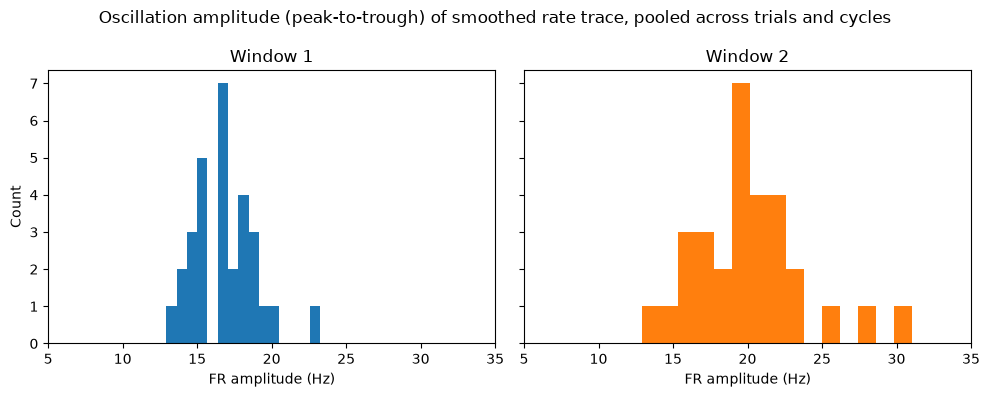

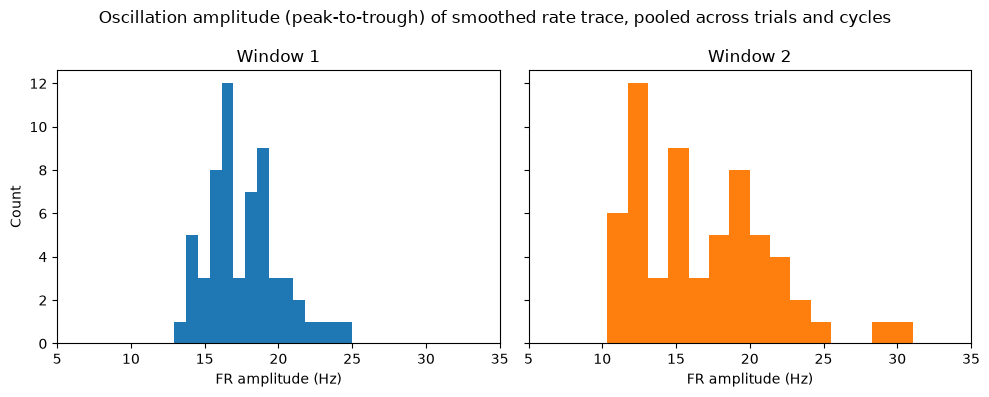

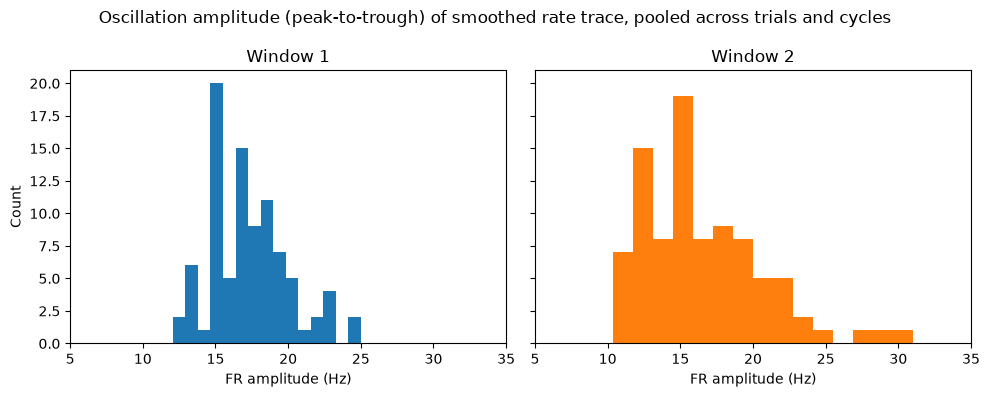

In [141]:
# plot histogram of FR amplitude (peak-to-trough) for each LGN unit, across all trials in a given cycle
cycle_start = np.array([[0, 48, 67], [7, 30, 76], [16, 39, 60]])  # nominal start times of each trial (search window; refined via chirp detection)
# [0, 48, 67] for 12hz
# [7, 30, 76] for 4+12hz
# [16, 39, 60] for 18+ 12hz
start_time = np.array([1893, 2971])  # [no-mask, mask]
lapse_s = 4  # covers trial_start_1..trial_end_2 below (two 2s halves)
stim_hz = ["12", "NA", "4", "4-12", "18", "18-12"]

unit_ids = list(lgn_spike_times.keys())
n_units = len(unit_ids)

pooled_ratios = []
pooled_sems = []
pooled_trial_ratios = []
pooled_labels = []

amplitude_1_all = []
amplitude_2_all = []

for i in range(3):
    first_trial_start_s = start_time[1] + cycle_start[i]
    trial_period_s = 90       # nominal spacing between trials
    lapse_s = 8               # window length per trial, from each trial's aligned start
    n_trials = 10                # number of trials to average
    bin_size_s = 0.01            # firing-rate bin width (s)
    smooth_bins = 4              # moving-average window, in bins

    trial_start_times = np.array([first_trial_start_s + i * trial_period_s for i in range(n_trials)]).flatten()

    bin_edges = np.arange(0, lapse_s + bin_size_s, bin_size_s)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    n_units = len(lgn_spike_times)

    show_bnc = bool(nidq_file_path)
    if show_bnc:
        nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
        nidq_fs = nidq_recording.get_sampling_frequency()
        bnc_channel_id = nidq_recording.channel_ids[0]

    trial_rates = []
    trial_bnc_traces = []
    for k in range(len(trial_start_times)):
        nominal_start = trial_start_times[k]
        trial_start = nominal_start
        if show_bnc:
            # re-center each trial on its actual chirp onset, same logic as plot_raster,
            # since the ~90s cadence isn't perfectly accurate
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
            )
            onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
            if onsets.size:
                trial_start = onsets[0] - 0.5
            trial_end = trial_start + lapse_s
            trial_start_times[k] = trial_start + 0.5

        pooled_spikes = np.concatenate([
            times[(times >= trial_start) & (times < trial_end)] - trial_start
            for times in lgn_spike_times.values()
        ]) if n_units else np.array([])
        counts, _ = np.histogram(pooled_spikes, bins=bin_edges)
        trial_rates.append(counts / (bin_size_s * n_units))

    trial_rates = np.array(trial_rates)

    for t in range(len(trial_start_times)):
        trial_start_1 = trial_start_times[t]
        trial_end_1 = trial_start_1 + 2
        trial_start_2 = trial_end_1
        trial_end_2 = trial_start_2 + 2

        smoothed_rate = np.convolve(trial_rates[t], np.ones(smooth_bins) / smooth_bins, mode="same")
        in_window_1 = (bin_centers >= trial_start_1 - trial_start_times[t]) & (bin_centers < trial_end_1 - trial_start_times[t])
        in_window_2 = (bin_centers >= trial_start_2 - trial_start_times[t]) & (bin_centers < trial_end_2 - trial_start_times[t])

        amplitude_1_all.append(smoothed_rate[in_window_1].max() - smoothed_rate[in_window_1].min())
        amplitude_2_all.append(smoothed_rate[in_window_2].max() - smoothed_rate[in_window_2].min())

    # --- Histogram of the smoothed-rate peak-to-trough amplitude in each of the 2 time windows,
    # pooled across all trials and cycles ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    axes[0].hist(amplitude_1_all, bins=15, color="tab:blue")
    axes[0].set_xlabel("FR amplitude (Hz)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Window 1")
    axes[0].set_xlim(5, 35)

    axes[1].hist(amplitude_2_all, bins=15, color="tab:orange")
    axes[1].set_xlabel("FR amplitude (Hz)")
    axes[1].set_title("Window 2")
    axes[1].set_xlim(5, 35)

    fig.suptitle("Oscillation amplitude (peak-to-trough) of smoothed rate trace, pooled across trials and cycles")
    plt.tight_layout()
    plt.show()
